In [1]:
from IndividualParcellation.global_config import *
import pickle
import numpy as np
import pandas as pd
import torch as pt
import nitools as nt
import seaborn as sns
import SUITPy.flatmap as flatmap
import matplotlib.pyplot as plt
import nilearn.plotting as plotting
from Functional_Fusion.dataset import DataSetMDTB
from Functional_Fusion.dataset import DataSetLanguage
import Functional_Fusion.atlas_map as am
import HierarchBayesParcel.full_model as fm
import HierarchBayesParcel.util as ut
import HierarchBayesParcel.emissions as em
import HierarchBayesParcel.evaluation as ev
import PcmPy as pcm
import os


# Constants

For this analysis , I will use a mask that includes D + S regions

In [2]:
# Check if CUDA is available
device = pt.device('cuda' if pt.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


# make different ROIs

In [3]:
space = 'fs32k'
atlas,_= am.get_atlas(atlas_str=space)
base_dir = 'Y:/data/FunctionalFusion/'
if not os.path.exists(base_dir):
    base_dir = '/cifs/diedrichsen/data/FunctionalFusion/'

In [4]:
cort_dir = 'Y:/data/Atlas_templates/fs_LR_32'
  # Load surface files for left and right hemispheres
surfs = [f"{base_dir}/Atlases/tpl-fs32k/tpl-fs32k_hemi-{h}_inflated.surf.gii" for h in ['L', 'R']]
def plot_cortex(data, threshold=0.0, cmap='binary', figsize=(12, 6),title = 'figure'):  

    # Convert data to CIFTI format
    cifti = atlas.data_to_cifti(data)
    
    # Extract data for the cortical surfaces
    all_img = nt.surf_from_cifti(cifti)
    
    # Create the plot
    fig, axes = plt.subplots(1, 2, subplot_kw={'projection': '3d'}, figsize=figsize)
    for h, hemi in enumerate(['left', 'right']):
        plotting.plot_surf_stat_map(
            surfs[h], all_img[h], hemi=hemi,
            colorbar=False,
            cmap=cmap,
            axes=axes[h],
            threshold=threshold,
            title=f'{title} {hemi}',
        )
    
    return fig


In [5]:
# roi
atlas_dir = f'{base_dir}/Atlases/tpl-fs32k'
model_name_L = f'{atlas_dir}/HumanLobes.L.label.gii'
model_name_R = f'{atlas_dir}/HumanLobes.R.label.gii'
parcels = atlas.read_data([model_name_L,model_name_R])


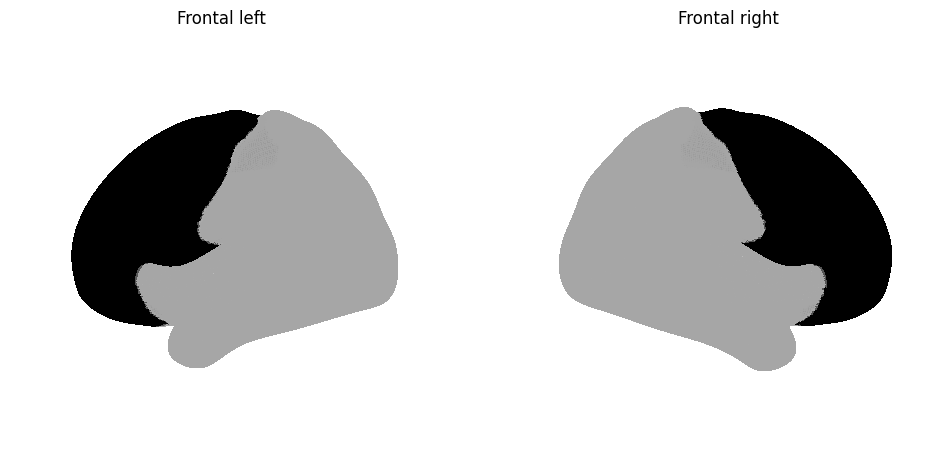

In [6]:
ROI_frontal = np.isin(parcels, [1]).astype(int)[np.newaxis, :]
fig = plot_cortex(ROI_frontal, threshold=0.1, cmap='binary', figsize=(12, 6),title='Frontal')
plt.show()

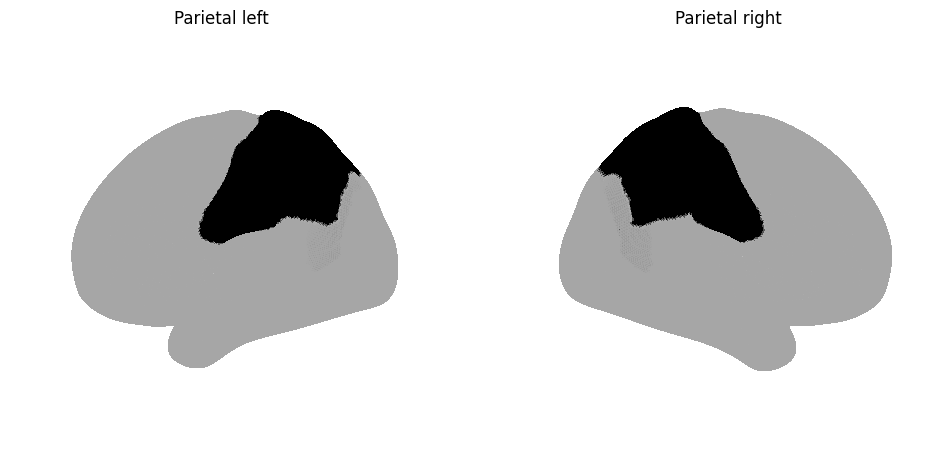

In [7]:
ROI_parietal = np.isin(parcels, [2]).astype(int)[np.newaxis, :]
fig = plot_cortex(ROI_parietal, threshold=0.1, cmap='binary', figsize=(12, 6),title='Parietal')
plt.show()

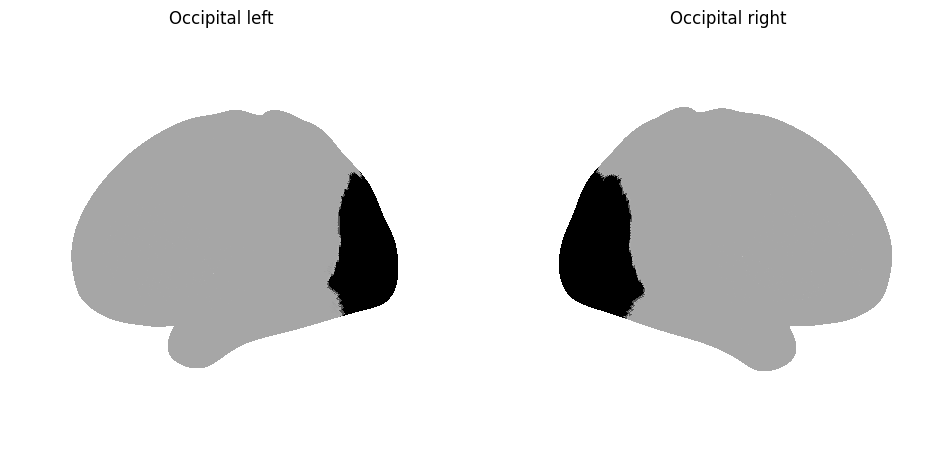

In [8]:
ROI_occipital = np.isin(parcels, [5]).astype(int)[np.newaxis, :]
fig = plot_cortex(ROI_occipital, threshold=0.1, cmap='binary', figsize=(12, 6),title='Occipital')
plt.show()

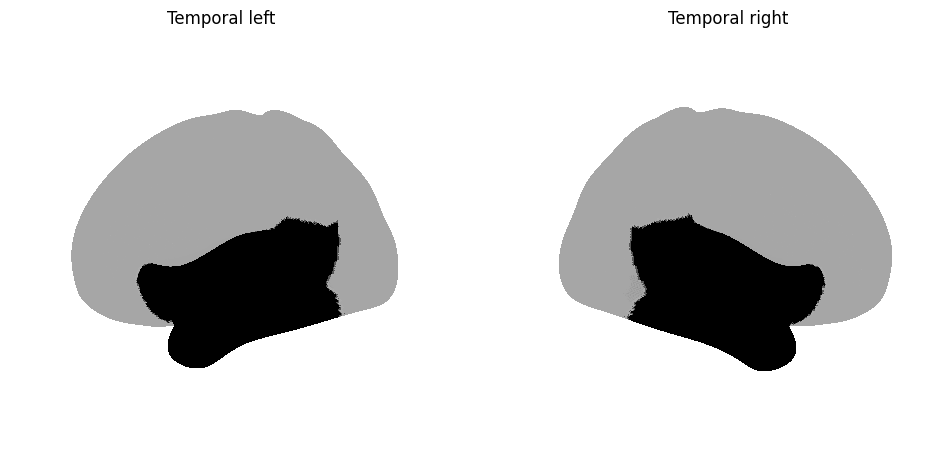

In [9]:
ROI_temporal = np.isin(parcels, [4]).astype(int)[np.newaxis, :]
fig = plot_cortex(ROI_temporal, threshold=0.1, cmap='binary', figsize=(12, 6),title='Temporal')
plt.show()

# Load data

In [6]:
MDTB_dataset = DataSetMDTB(f'{base_dir}/MDTB')
data_mdtb_s1,info_mdtb_1  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun')
data_mdtb_s1[np.isnan(data_mdtb_s1)] = 0
task_names = info_mdtb_1.cond_name.values

In [7]:
cond_vec = np.tile(np.arange(1, 29 + 1), 16)
part_vec = np.repeat(np.arange(1, 16 + 1), 29)
task_names = info_mdtb_1[:29].cond_name.values
def get_G(data,cond_vec,part_vec):
    Gs_list = []
    for i in range(data.shape[0]):
        Gs,E = pcm.util.est_G_crossval(data[i], cond_vec, part_vec)
        Gs_list.append(Gs)
    Gs_list = np.stack(Gs_list, 0)
    G_individuals_averaged = np.mean(Gs_list, axis=0)

    return G_individuals_averaged

vmin = -0.025
vmax = 0.025

Text(0.5, 1.0, 'Frontal')

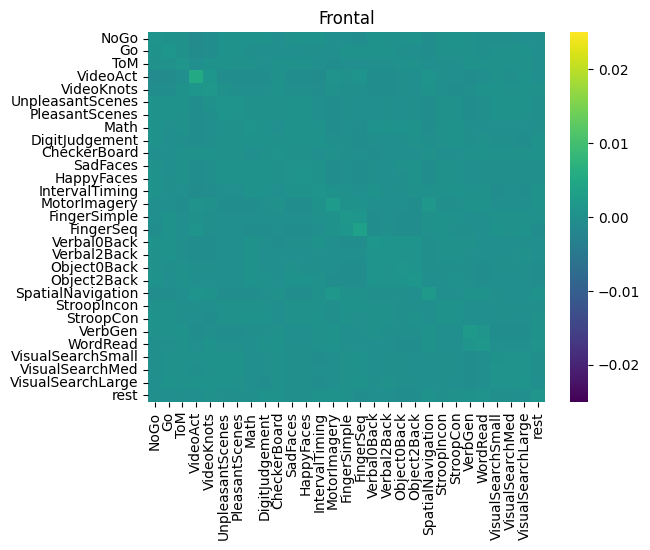

In [ ]:
data_mdtb_s1_frontal = data_mdtb_s1[:,:,:] * ROI_frontal
G_frontal = get_G(data_mdtb_s1_frontal,cond_vec,part_vec)
sns.heatmap(G_frontal, xticklabels=task_names, yticklabels=task_names, cmap='viridis',vmin = vmin, vmax = vmax)
plt.title('Frontal')

Text(0.5, 1.0, 'Parietal')

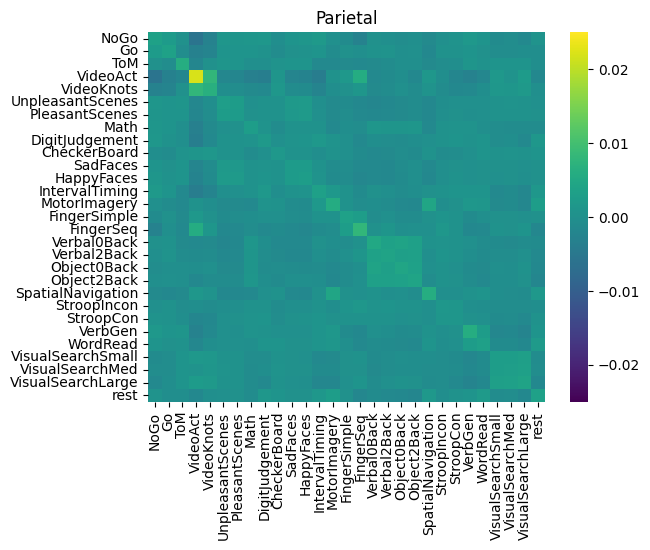

In [84]:
data_mdtb_s1_parietal = data_mdtb_s1[:,:,:] * ROI_parietal
G_parietal = get_G(data_mdtb_s1_parietal,cond_vec,part_vec)
sns.heatmap(G_parietal, xticklabels=task_names, yticklabels=task_names, cmap='viridis',vmin = vmin, vmax = vmax)
plt.title('Parietal')

Text(0.5, 1.0, 'Occipital')

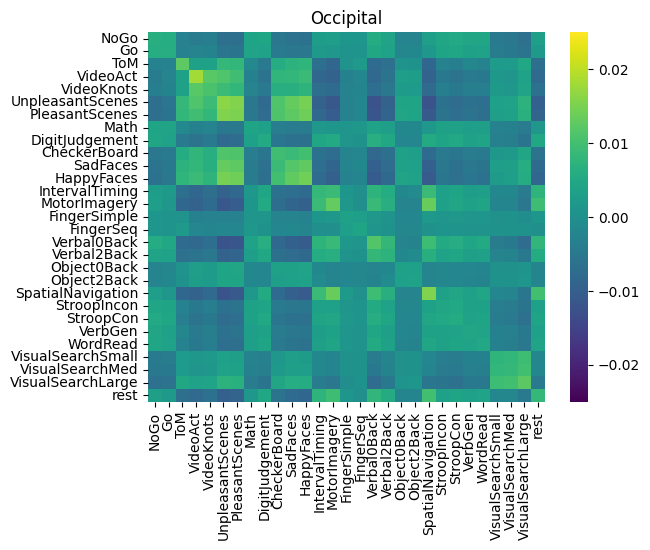

In [85]:
data_mdtb_s1_occipital = data_mdtb_s1[:,:,:] * ROI_occipital
G_occipital = get_G(data_mdtb_s1_occipital,cond_vec,part_vec)
sns.heatmap(G_occipital, xticklabels=task_names, yticklabels=task_names, cmap='viridis',vmin = vmin, vmax = vmax)
plt.title('Occipital')


Text(0.5, 1.0, 'Temporal')

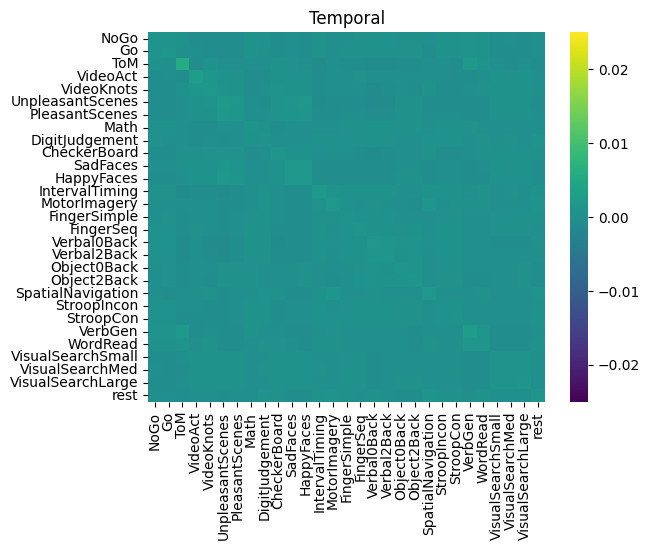

In [86]:
data_mdtb_s1_temporal = data_mdtb_s1[:,:,:] * ROI_temporal
G_temporal = get_G(data_mdtb_s1_temporal,cond_vec,part_vec)
sns.heatmap(G_temporal, xticklabels=task_names, yticklabels=task_names, cmap='viridis',vmin = vmin, vmax = vmax)
plt.title('Temporal')


# Motor vs prefrontal cortex

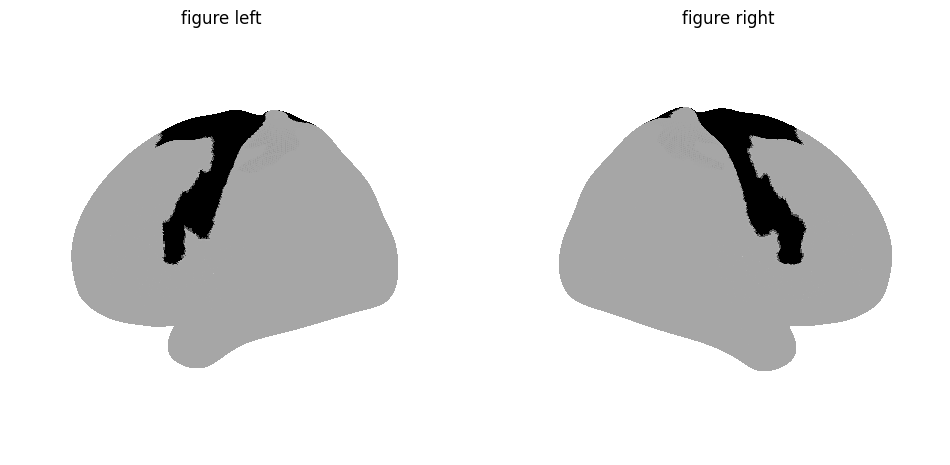

In [8]:
# roi
atlas_dir = f'{base_dir}/Atlases/tpl-fs32k'
model_name_L = f'{atlas_dir}/glasser.L.label.gii'
model_name_R = f'{atlas_dir}/glasser.R.label.gii'
parcels = atlas.read_data([model_name_L,model_name_R])

ROI_motor = np.isin(parcels, [53,9,8,39,36,37,96,54,44,55,78,56,42]).astype(int)[np.newaxis, :]
fig = plot_cortex(ROI_motor, threshold=0.1, cmap='binary', figsize=(12, 6))
plt.show()


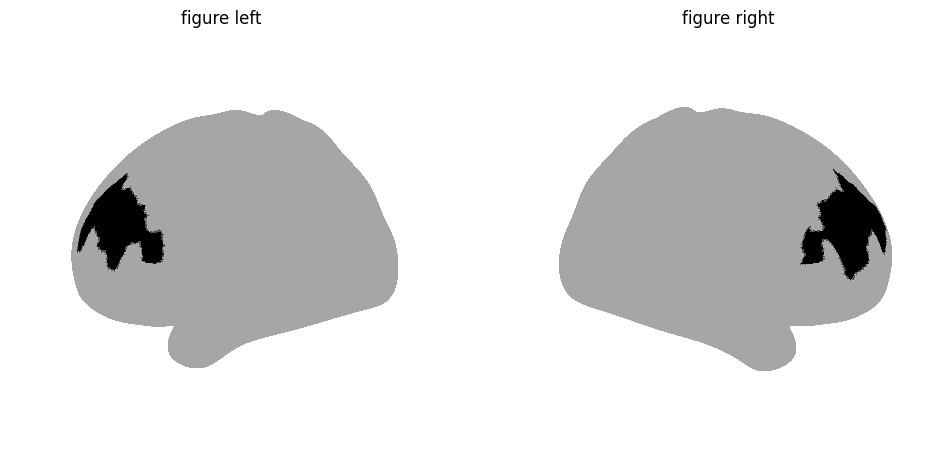

In [9]:
ROI_PFC = np.isin(parcels, [74,81,82,83,84,86]).astype(int)[np.newaxis, :]
fig = plot_cortex(ROI_PFC, threshold=0.1, cmap='binary', figsize=(12, 6))
plt.show()

In [ ]:
data_mdtb_s1_motor = data_mdtb_s1[:,:,:] * ROI_motor
G_motor = get_G(data_mdtb_s1_motor,cond_vec,part_vec)



In [40]:
vmin = -0.003
vmax = 0.003

Text(0.5, 1.0, 'Motor')

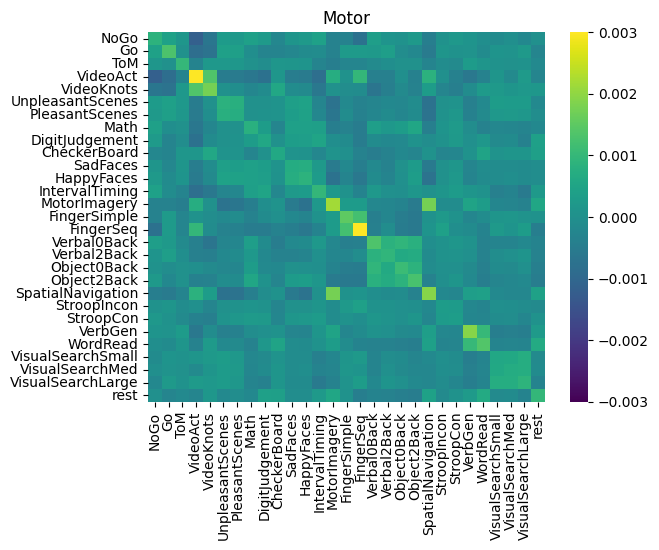

In [41]:
sns.heatmap(G_motor, xticklabels=task_names, yticklabels=task_names, cmap='viridis',vmin = vmin, vmax = vmax)
plt.title('Motor')

In [13]:
data_mdtb_s1_PFC = data_mdtb_s1[:,:,:] * ROI_PFC
G_PFC = get_G(data_mdtb_s1_PFC,cond_vec,part_vec)


Text(0.5, 1.0, 'PFC')

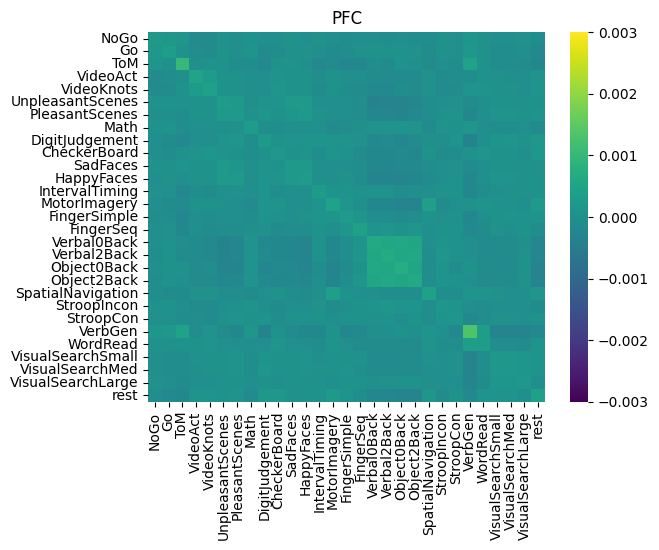

In [42]:
sns.heatmap(G_PFC, xticklabels=task_names, yticklabels=task_names, cmap='viridis',vmin = vmin, vmax = vmax)
plt.title('PFC')